In [1]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import laboneq
from datetime import datetime

print(laboneq.__version__)

2.51.0


In [2]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.23 20:21:18.776] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.23 20:21:18.779] INFO    VERSION: laboneq 2.51.0
[2025.08.23 20:21:18.782] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.23 20:21:18.788] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.23 20:21:18.794] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.23 20:21:18.798] INFO    Configuring the device setup
[2025.08.23 20:21:18.807] INFO    The device setup is configured


In [10]:
class qubit_spec:
    """
    Qubit Spectroscopy helper (class version mirroring resonator_spec style).

    STAGE-Q API:
      - run(save_pulse_sheet=True, simulate=False)
      - analyze(amplitude_mode="real")   # "real" to match your current code, or "abs"
      - plot(save_png=True)

    Stored results after analyze():
      self.freq_Hz, self.iq_complex, self.amp_dbm, self.phase_rad
    """

    # -------------------------- #
    # Construction & parameters  #
    # -------------------------- #
    def __init__(
        self,
        *,
        device_setup,
        session,
        qubit: str = "q0",

        # LOs and frequencies
        qb_lo_freq: float = 3e9,            # LO for drive
        res_lo_freq: float = 7.2e9,         # LO for readout
        res_freq: float = 7.148812e9,       # absolute resonator frequency (Hz)

        # Sweep window (relative to qb_lo_freq)
        start_freq: float = -100e6,
        stop_freq: float = 300e6,
        num_points: int = 101,

        # Acquisition averages & timing
        num_averages: int = 9,              # power of two (2**num_averages)
        integration_time: float = 1e-5,

        # Calibrations (ranges in dBm, pulses in [0..1] scale)
        drive_amp: float = -30,           # range for drive signal calibration
        drive_pulse_length: float = 5e-6,
        drive_pulse_amp: float = 1.0,       # waveform amplitude (dimensionless)

        measure_range: float = -35,
        measure_amp: float = 0.4,           # readout pulse amplitude (dimensionless)
        ro_pulse_length: float = 5e-6,
        ro_pulse_amp: float = 0.08,

        acquire_range: float = -35,
        acquire_amp: float = 0.8,

        outdir: str = "qubit_results",
        results_prefix: str | None = None,
    ):
        # External handles
        self.device_setup = device_setup
        self.session = session
        self.qubit = str(qubit)

        # Frequencies (LOs)
        self.qb_lo_freq = float(qb_lo_freq)
        self.res_lo_freq = float(res_lo_freq)
        self.res_freq = float(res_freq)

        # Sweep
        self.start_freq = float(start_freq)
        self.stop_freq = float(stop_freq)
        self.num_points = int(num_points)

        # Acquisition timing and averaging
        self.num_averages = int(num_averages)
        self.integration_time = float(integration_time)

        # Calibrations/pulses
        self.drive_amp = float(drive_amp)
        self.drive_pulse_length = float(drive_pulse_length)
        self.drive_pulse_amp = float(drive_pulse_amp)

        self.measure_range = float(measure_range)
        self.measure_amp = float(measure_amp)
        self.ro_pulse_length = float(ro_pulse_length)
        self.ro_pulse_amp = float(ro_pulse_amp)

        self.acquire_range = float(acquire_range)
        self.acquire_amp = float(acquire_amp)

        # I/O & naming
        self.outdir = Path(outdir); self.outdir.mkdir(parents=True, exist_ok=True)
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.results_prefix = results_prefix or f"qspec_{ts}"

        # Containers
        self._freq_sweep = None
        self._exp = None
        self._compiled = None
        self._result = None

        # Analysis products
        self.freq_Hz = None
        self.iq_complex = None
        self.amp_dbm = None
        self.phase_rad = None

    # -------------------------- #
    # Building blocks            #
    # -------------------------- #
    def _create_readout_pulse(self):
        return pulse_library.const(
            uid=f"readout_pulse_{self.qubit}",
            length=self.ro_pulse_length,
            amplitude=self.ro_pulse_amp,
        )

    def _create_drive_pulse(self):
        return pulse_library.const(
            uid=f"drive_spec_pulse_{self.qubit}",
            length=self.drive_pulse_length,
            amplitude=self.drive_pulse_amp,
        )

    def _create_drive_freq_sweep(self):
        return LinearSweepParameter(
            uid=f"drive_freq_{self.qubit}",
            start=self.start_freq,
            stop=self.stop_freq,
            count=self.num_points,
        )

    def _build_experiment(self, freq_sweep, drive_pulse, readout_pulse):
        """
        Matches your qubit_spectroscopy() function.
        Drive → Readout/Acquire → Relax
        """
        exp = Experiment(
            uid="Qubit Spectroscopy",
            signals=[ExperimentSignal("drive"), ExperimentSignal("measure"), ExperimentSignal("acquire")],
        )
        with exp.acquire_loop_rt(
            uid="freq_shots",
            count=2**self.num_averages,
            acquisition_type=AcquisitionType.INTEGRATION,
        ):
            with exp.sweep(uid="qfreq_sweep", parameter=freq_sweep):
                with exp.section(uid="qubit_excitation"):
                    exp.play(signal="drive", pulse=drive_pulse)
                with exp.section(uid="readout_section", play_after="qubit_excitation"):
                    exp.play(signal="measure", pulse=readout_pulse)
                    exp.acquire(signal="acquire", handle="qb_spec", kernel=readout_pulse)
                with exp.section(uid="relax", length=100e-6):
                    exp.reserve(signal="measure")
                    exp.reserve(signal="acquire")
        return exp

    def _make_calibration(self, freq_sweep):
        """
        Mirrors your exp_calibration:
          - drive uses qb LO and the freq sweep oscillator
          - measure uses res LO and (res_freq - res_lo_freq)
          - acquire has its range/amplitude set
        """
        calib = Calibration()
        calib["drive"] = SignalCalibration(
            oscillator=Oscillator(uid="ch0_osc_0", frequency=freq_sweep, modulation_type=ModulationType.HARDWARE),
            local_oscillator=Oscillator(uid="ch0_lo", frequency=self.qb_lo_freq),
            range=self.drive_amp,
        )
        calib["measure"] = SignalCalibration(
            oscillator=Oscillator(uid="qa_osc_0", frequency=self.res_freq - self.res_lo_freq, modulation_type=ModulationType.HARDWARE),
            local_oscillator=Oscillator(uid="qa_lo", frequency=self.res_lo_freq),
            range=self.measure_range,
            amplitude=self.measure_amp,
        )
        calib["acquire"] = SignalCalibration(
            range=self.acquire_range,
            amplitude=self.acquire_amp,
        )
        return calib

    def _make_signal_map(self):
        lsg = self.device_setup.logical_signal_groups[self.qubit].logical_signals
        return {
            "drive":   lsg["drive_line"],
            "measure": lsg["measure_line"],
            "acquire": lsg["acquire_line"],
        }

    # -------------------------- #
    # Stage-Q: run/analyze/plot  #
    # -------------------------- #
    def run(self, save_pulse_sheet: bool = True, simulate: bool = False):
        """
        Build → compile → (optional pulse sheet/simulate) → run.
        Stores self._result.
        """
        # sweep + pulses
        self._freq_sweep = self._create_drive_freq_sweep()
        drive_pulse = self._create_drive_pulse()
        readout_pulse = self._create_readout_pulse()

        # experiment
        self._exp = self._build_experiment(self._freq_sweep, drive_pulse, readout_pulse)
        self._exp.set_calibration(self._make_calibration(self._freq_sweep))
        self._exp.set_signal_map(self._make_signal_map())

        # compile
        self._compiled = self.session.compile(self._exp)

        # pulse sheet
        if save_pulse_sheet:
            Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
            show_pulse_sheet(str(Path("Pulse_Sheets") / "Qubit_Spectroscopy"), self._compiled)

        # optional simulation (if your stack supports it)
        if simulate:
            try:
                plot_simulation(self._compiled, start_time=0, length=20e-6)
            except Exception:
                pass

        # run
        self._result = self.session.run(self._compiled)

        # save raw JSON if you like
        try:
            timestamp = time.strftime("%Y%m%dT%H%M%S")
            Path("Results").mkdir(parents=True, exist_ok=True)
            save(self._result, f"Results/{timestamp}_qspec_results.json")
        except Exception:
            pass

        return self._result

    def analyze(self, amplitude_mode: str = "real"):
        """
        Pulls frequency axis and IQ, computes amplitude (in dBm) and phase (rad).

        amplitude_mode:
          - "real" → uses np.real(IQ) like your current code
          - "abs"  → uses |IQ|
        """
        if self._result is None:
            raise RuntimeError("Run .run() first.")

        # Frequencies (Hz) and complex IQ
        freqs = np.asarray(self._result.acquired_results["qb_spec"].axis[0]).ravel()
        iq = np.asarray(self._result.acquired_results["qb_spec"].data).ravel()

        # Amplitude
        if amplitude_mode.lower() == "abs":
            amplitude = np.abs(iq)
        else:
            amplitude = iq.real  # match your original script

        # Convert to dBm
        power_W = (amplitude**2) / 50.0
        with np.errstate(divide="ignore", invalid="ignore"):
            amp_dbm = 10.0 * np.log10(power_W / 1e-3)

        # Phase
        phase_rad = np.angle(iq)  # already wraps to [-π, π]

        # Store
        self.freq_Hz = freqs
        self.iq_complex = iq
        self.amp_dbm = amp_dbm
        self.phase_rad = phase_rad

        # Save CSV
        try:
            np.savetxt(
                self.outdir / f"{self.results_prefix}_qspec.csv",
                np.column_stack([self.freq_Hz, amplitude, self.amp_dbm, self.phase_rad]),
                delimiter=",",
                header="freq_Hz, amplitude_linear, amplitude_dBm, phase_rad",
            )
        except Exception:
            pass

        return {
            "freq_Hz": self.freq_Hz,
            "iq": self.iq_complex,
            "amp_dbm": self.amp_dbm,
            "phase_rad": self.phase_rad,
        }

    def plot(self, save_png: bool = True, title: str | None = None):
        """
        Two-panel plot (amplitude in dBm, phase in rad) vs frequency (GHz).
        """
        if any(x is None for x in [self.freq_Hz, self.amp_dbm, self.phase_rad]):
            raise RuntimeError("Run .analyze() first.")

        fGHz = (self.freq_Hz+self.qb_lo_freq) / 1e9
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [1.5, 1.0]}
        )

        # Amplitude
        ax1.plot(fGHz, self.amp_dbm, "o-", markersize=3)
        ax1.set_ylabel("Amplitude [dBm]")
        ax1.set_title(title or "Qubit Spectroscopy")

        # Phase
        ax2.plot(fGHz, self.phase_rad, "o-", markersize=3, color="tab:purple")
        ax2.set_xlabel("Frequency [GHz]")
        ax2.set_ylabel("Phase [rad]")

        plt.tight_layout()

        png = None
        if save_png:
            png = self.outdir / f"{self.results_prefix}_qspec.png"
            fig.savefig(png, dpi=300)

        return fig, {"png": str(png) if png else None}

    # Convenience: get raw arrays (after analyze)
    def get_arrays(self):
        if any(x is None for x in [self.freq_Hz, self.iq_complex, self.amp_dbm, self.phase_rad]):
            raise RuntimeError("Run .analyze() first.")
        return self.freq_Hz, self.iq_complex, self.amp_dbm, self.phase_rad


[2025.08.23 20:36:46.332] INFO    Starting LabOne Q Compiler run...
[2025.08.23 20:36:46.354] INFO    Schedule completed. [0.020 s]


[2025.08.23 20:36:46.415] INFO    Code generation completed for all AWGs. [0.059 s]
[2025.08.23 20:36:46.415] INFO    Completed compilation step 1 of 1. [0.081 s]
[2025.08.23 20:36:46.419] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.23 20:36:46.420] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.23 20:36:46.420] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.23 20:36:46.421] INFO      device_shfqc        0         10            0           1      4000  
[2025.08.23 20:36:46.421] INFO      device_shfqc_sg     1         23            2           1      4000  
[2025.08.23 20:36:46.423] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.23 20:36:46.424] INFO      TOTAL                         33            2                  8000  
[2025.08.23 20:36:46.425] INFO     ────────────────────────────────────────────────────────────

(<Figure size 900x600 with 2 Axes>,
 {'png': 'qubit_results\\qspec_20250823_203646_qspec.png'})

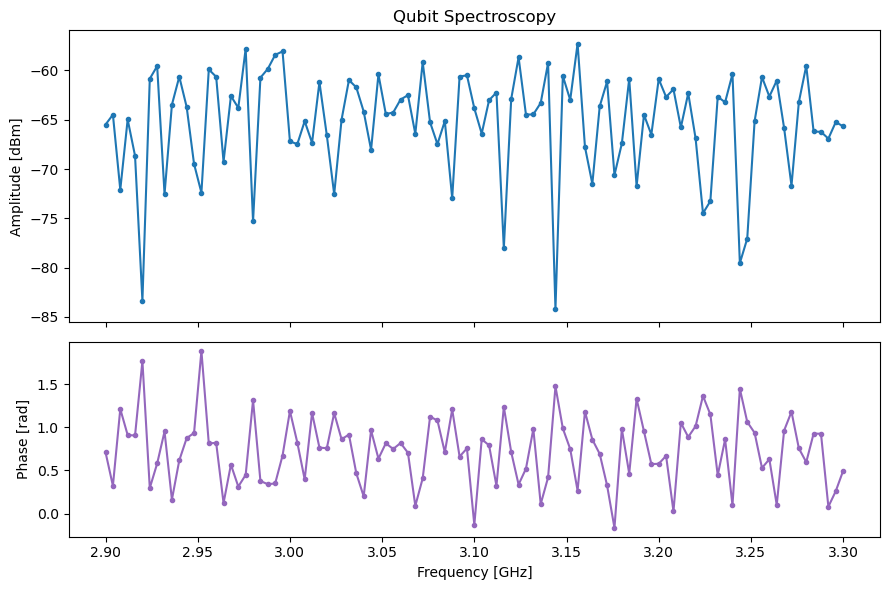

In [ ]:
# Create helper
qs = qubit_spec(
    device_setup=device_setup,
    session=session,
    qubit="q0",
    qb_lo_freq=3e9,
    res_lo_freq=7.2e9,
    res_freq=7.148812e9,
    start_freq=-100e6,
    stop_freq=300e6,
    num_points=101,
    num_averages=8,
    integration_time=1e-5,
    drive_amp=-30,
    drive_pulse_length=1e-6,
    drive_pulse_amp=1,
    measure_range=-30,
    measure_amp=0.3,
    ro_pulse_length=1e-6,
    ro_pulse_amp=0.08,
    acquire_range=-40,
    acquire_amp=0.7,
)

# Build/compile/run (pulse sheet optional)
qs.run(save_pulse_sheet=True, simulate=False)

# Analyze (use "real" to match your previous script; use "abs" if you prefer |IQ|)
qs.analyze(amplitude_mode="real")

# Plot
qs.plot(save_png=True)

In [ ]:
# pulse parameters and definitions
def create_readout_pulse(
    qubit, length=ro_pulse_length, amplitude=ro_pulse_amp):
    readout_pulse = pulse_library.const(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude)
    return readout_pulse

def create_drive_pulse(qubit, length=drive_pulse_length, amplitude=drive_pulse_amp):
    pulse = pulse_library.const(
        uid=f"drive_spec_pulse_{qubit}", length=length, amplitude=amplitude)
    return pulse

def create_drive_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"drive_freq_{qubit}", start=start_freq, stop=stop_freq, count=num_points
    )

In [ ]:
# function that returns a qubit spectroscopy experiment- accepts frequency sweep range as parameter
def qubit_spectroscopy(freq_sweep, drive_pulse, readout_pulse):
    # Create qubit spectroscopy Experiment - uses qubit drive, readout drive and data acquisition lines
    exp_qspec = Experiment(
        uid="Qubit Spectroscopy",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    # inner loop - real-time averaging - QA in integration mode
    with exp_qspec.acquire_loop_rt(
        uid="freq_shots",
        count=2**num_averages,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        with exp_qspec.sweep(uid="qfreq_sweep", parameter=freq_sweep):
            # qubit drive
            with exp_qspec.section(uid="qubit_excitation"):
                exp_qspec.play(signal="drive", pulse=drive_pulse)
            with exp_qspec.section(
                uid="readout_section", play_after="qubit_excitation"
            ):
                # play readout pulse on measure line
                exp_qspec.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_qspec.acquire(
                    signal="acquire",
                    handle="qb_spec",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_qspec.section(uid="relax", length=100e-6):
                exp_qspec.reserve(signal="measure")
                exp_qspec.reserve(signal='acquire')

    return exp_qspec

In [ ]:
# frequency range of spectroscopy scan - defined around expected qubit frequency as defined in qubit parameters
freq_sweep_q0 = create_drive_freq_sweep("q0", start_freq, stop_freq, num_points)

# experiment signal calibration for qubit 0
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = freq_sweep_q0,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = -30)

exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = -30)

exp_calibration["acquire"] = SignalCalibration(range = acquire_range, amplitude= acquire_amp)

# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map

# define experiment with frequency sweep for qubit 0
drive_pulse = create_drive_spec_pulse("q0")
readout_pulse = create_readout_pulse("q0", sigma=0.2, width=1e-6)

exp_qspec = qubit_spectroscopy(freq_sweep_q0, drive_pulse, readout_pulse)

# apply calibration and signal map for qubit 0
exp_qspec.set_calibration(exp_calibration)
exp_qspec.set_signal_map(signal_map_default("q0"))

In [ ]:
# compile the experiment on the open instrument session
compiled_qspec = session.compile(exp_qspec)
Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Qubit_Spectroscopy", compiled_qspec)

[2025.08.23 15:06:21.411] INFO    Starting LabOne Q Compiler run...
[2025.08.23 15:06:21.440] INFO    Schedule completed. [0.026 s]
[2025.08.23 15:06:21.499] INFO    Code generation completed for all AWGs. [0.057 s]
[2025.08.23 15:06:21.500] INFO    Completed compilation step 1 of 1. [0.086 s]
[2025.08.23 15:06:21.504] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.23 15:06:21.505] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.23 15:06:21.506] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.23 15:06:21.507] INFO      device_shfqc        0         10            0           1      4000  
[2025.08.23 15:06:21.508] INFO      device_shfqc_sg     1         23            2           1     20000  
[2025.08.23 15:06:21.508] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.23 15:06:21.509] INFO      TOTAL                         33 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Qubit_Spectroscopy_2025-08-23-15-06-21.html

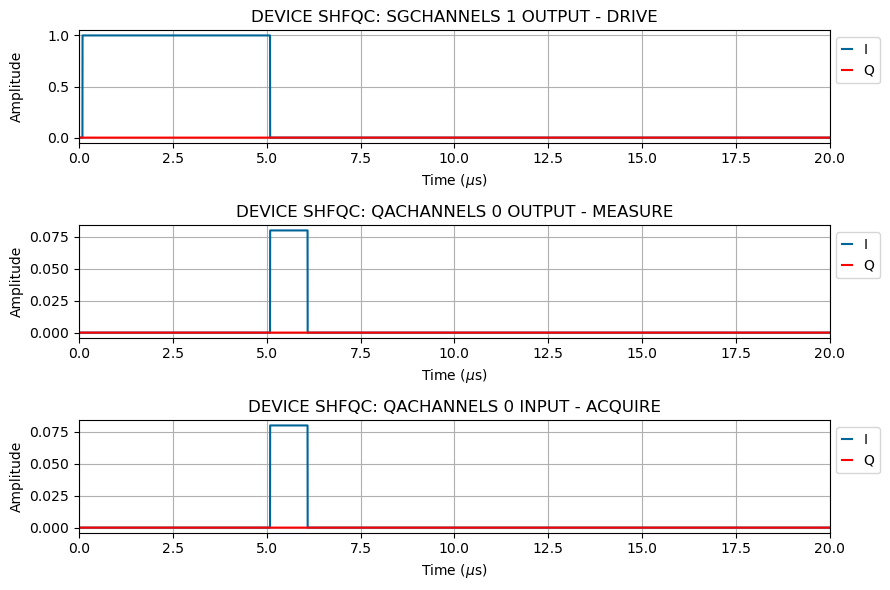

In [ ]:
plot_simulation(compiled_qspec, start_time=0, length=20e-6)

In [ ]:
# run the compiled experiemnt
qspec_results = session.run(compiled_qspec)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(qspec_results, f"Results/{timestamp}_qspec_results.json")
print(f"File saved as Results/{timestamp}_qspec_results.json")

[2025.08.23 15:06:22.156] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.23 15:06:22.159] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.23 15:06:22.162] INFO    Configuring the device setup
[2025.08.23 15:06:22.171] INFO    The device setup is configured
[2025.08.23 15:06:22.516] INFO    Starting near-time execution...
[2025.08.23 15:06:22.575] INFO    Estimated RT execution time: 5.49 s.
[2025.08.23 15:06:28.200] INFO    Finished near-time execution.
File saved as Results/20250823T150628_qspec_results.json


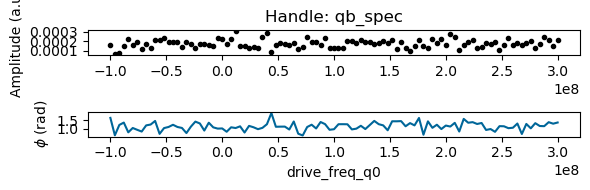

In [ ]:
plot_results(qspec_results, phase = True)

In [ ]:
# Frequencies in Hz
freqs = qspec_results.acquired_results["qb_spec"].axis[0]

# Complex IQ data
iq_data = qspec_results.acquired_results["qb_spec"].data

# Separate real and imaginary parts if needed
real_part = iq_data.real
imag_part = iq_data.imag

# Convert amplitude to dBm
# amplitude = np.abs(iq_data)
amplitude = real_part
power_W = (amplitude**2) / 50
amp_dbm = 10 * np.log10(power_W / 1e-3)

# Phase (radians)
phase_rad = np.angle(iq_data)


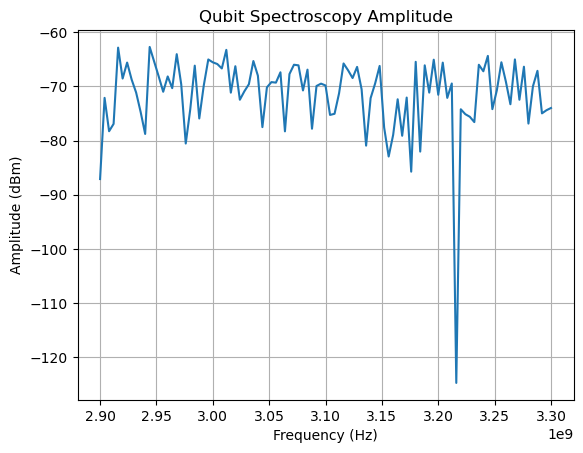

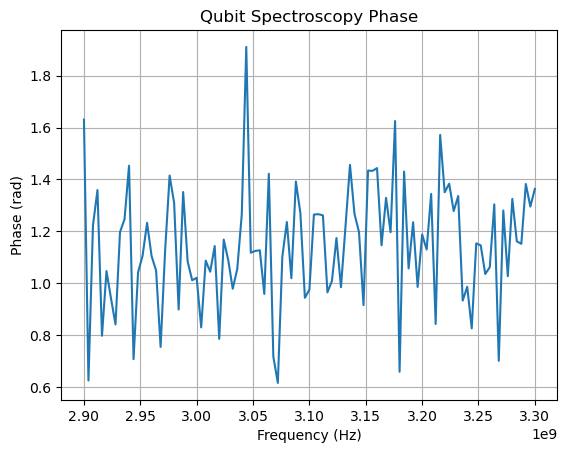

In [ ]:
freq_list = freqs + qb_lo_freq

plt.figure()
plt.plot(freq_list, amp_dbm)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dBm)")
plt.title("Qubit Spectroscopy Amplitude")
plt.grid(True)

plt.figure()
plt.plot(freq_list, phase_rad)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (rad)")
plt.title("Qubit Spectroscopy Phase")
plt.grid(True)

plt.show()
